In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from blimpy import Waterfall

from deepseti.injection.signals import inject_stationary_narrowband

/Users/parthshringarpure/deepseti/.venv/lib/python3.12/site-packages/blimpy/__init__.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
PROJECT_ROOT = Path.cwd().parent

test_file = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "dev_mid"
    / "spliced_blc0001020304050607_guppi_57635_40158_Hip13810_0018.gpuspec.0002.h5"
)

wf = Waterfall(
    str(test_file),
    f_start=2200,
    f_stop=2300,
)

data = wf.data.squeeze()

frame = data[:16, :4096]

print("Observation shape:", data.shape)
print("Frame shape:", frame.shape)

Observation shape: (273, 34952)
Frame shape: (16, 4096)


In [4]:
injected_frame, signal_mask = inject_stationary_narrowband(
    frame,
    frequency_bin=2000,
    snr=5.0,
    bandwidth_bins=1,
)

print("Original shape:", frame.shape)
print("Injected shape:", injected_frame.shape)
print("Injected pixels:", signal_mask.sum())

Original shape: (16, 4096)
Injected shape: (16, 4096)
Injected pixels: 16


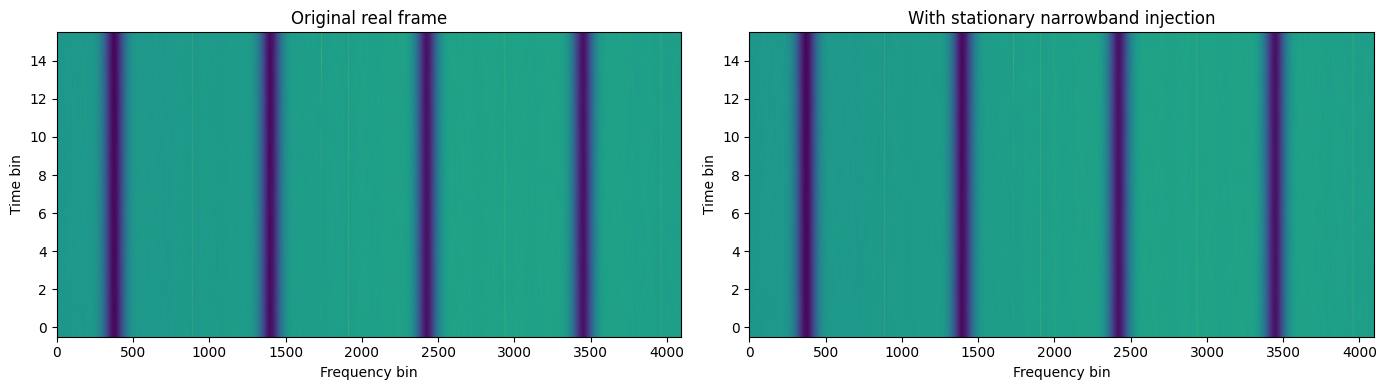

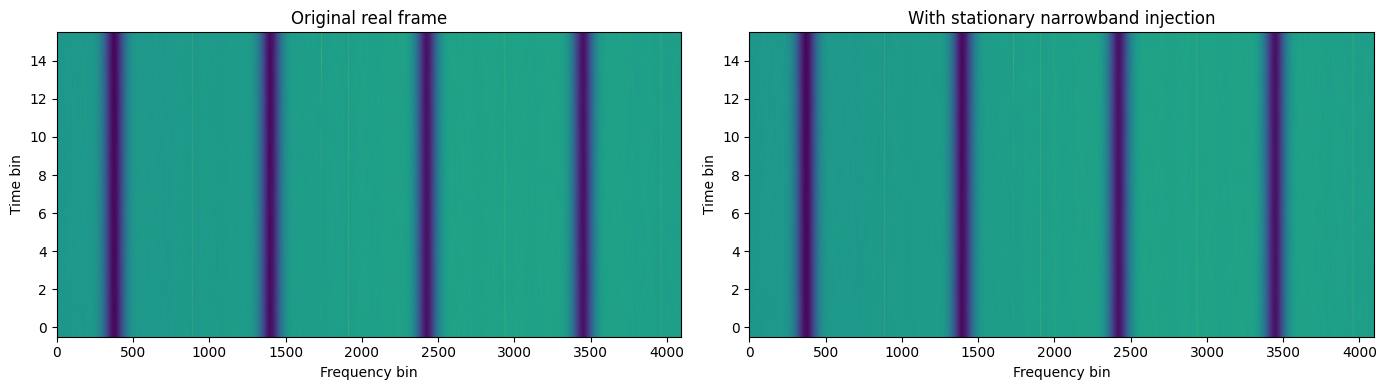

In [6]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(
    np.log10(frame),
    aspect="auto",
    origin="lower",
)
axes[0].set_title("Original real frame")
axes[0].set_xlabel("Frequency bin")
axes[0].set_ylabel("Time bin")

axes[1].imshow(
    np.log10(injected_frame),
    aspect="auto",
    origin="lower",
)
axes[1].set_title("With stationary narrowband injection")
axes[1].set_xlabel("Frequency bin")
axes[1].set_ylabel("Time bin")

plt.tight_layout()
plt.show()

In [ ]:
difference = injected_frame - frame

plt.figure(figsize=(12, 4))

plt.imshow(
    difference,
    aspect="auto",
    origin="lower",
)

plt.title("Synthetic signal added to real frame")
plt.xlabel("Frequency bin")
plt.ylabel("Time bin")

plt.show()

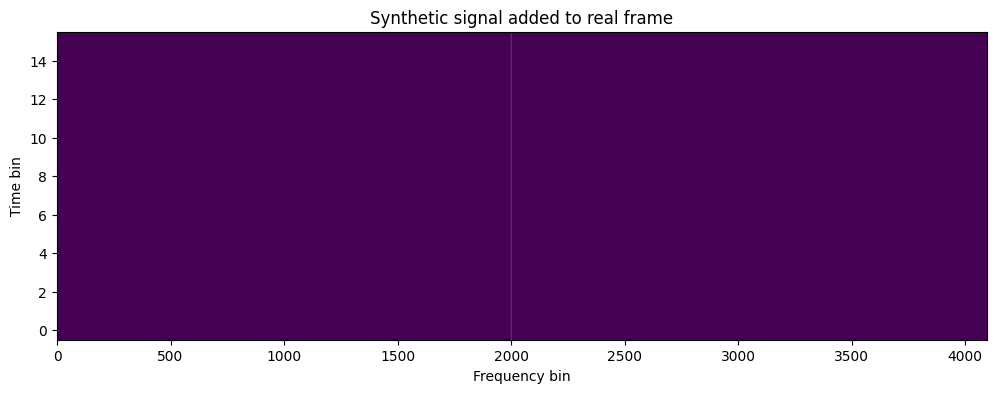

In [7]:
difference = injected_frame - frame

plt.figure(figsize=(12, 4))

plt.imshow(
    difference,
    aspect="auto",
    origin="lower",
)

plt.title("Synthetic signal added to real frame")
plt.xlabel("Frequency bin")
plt.ylabel("Time bin")

plt.show()

In [8]:
from deepseti.preprocessing.frames import robust_normalize_frame

original_normalized = robust_normalize_frame(frame)
injected_normalized = robust_normalize_frame(injected_frame)

print("Original normalized shape:", original_normalized.shape)
print("Injected normalized shape:", injected_normalized.shape)

print(
    "Mean value at injected bin before:",
    original_normalized[:, 2000].mean(),
)

print(
    "Mean value at injected bin after:",
    injected_normalized[:, 2000].mean(),
)

Original normalized shape: (16, 4096)
Injected normalized shape: (16, 4096)
Mean value at injected bin before: 0.949949
Mean value at injected bin after: 7.603671


In [9]:
import importlib
import deepseti.injection.signals as signals

importlib.reload(signals)

<module 'deepseti.injection.signals' from '/Users/parthshringarpure/deepseti/src/deepseti/injection/signals.py'>

In [10]:
drifted_frame, drift_mask = signals.inject_linear_drift(
    frame,
    start_frequency_bin=1900,
    drift_bins_per_time=10,
    snr=5.0,
)

print("Injected pixels:", drift_mask.sum())

Injected pixels: 16


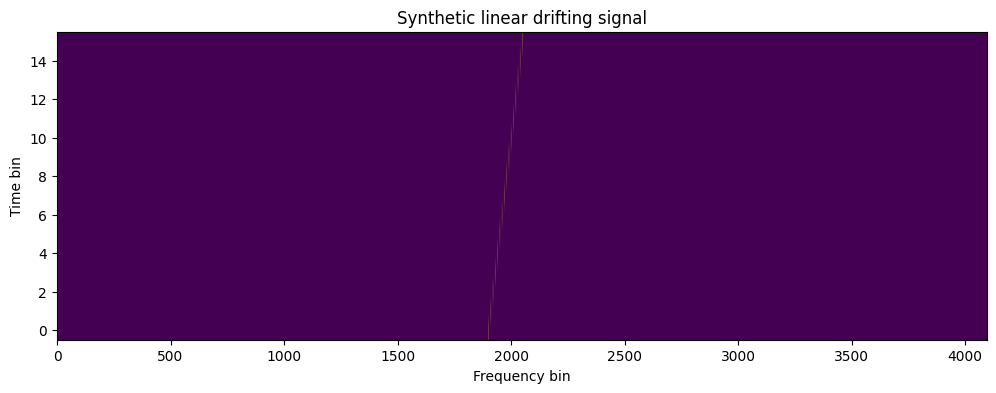

In [11]:
drift_difference = drifted_frame - frame

plt.figure(figsize=(12, 4))

plt.imshow(
    drift_difference,
    aspect="auto",
    origin="lower",
)

plt.title("Synthetic linear drifting signal")
plt.xlabel("Frequency bin")
plt.ylabel("Time bin")

plt.show()

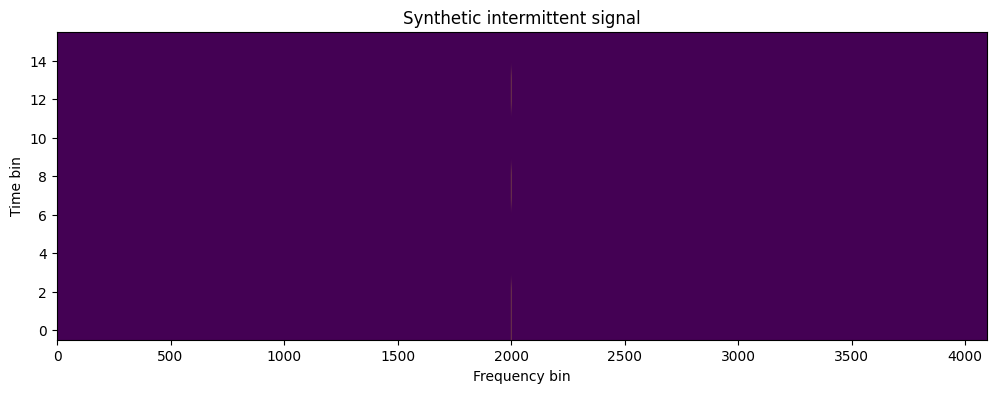

In [12]:
import importlib
import deepseti.injection.signals as signals

importlib.reload(signals)

intermittent_frame, intermittent_mask = signals.inject_intermittent(
    frame,
    frequency_bin=2000,
    snr=5.0,
    active_time_bins=[0, 1, 2, 7, 8, 12, 13],
)

intermittent_difference = intermittent_frame - frame

plt.figure(figsize=(12, 4))

plt.imshow(
    intermittent_difference,
    aspect="auto",
    origin="lower",
)

plt.title("Synthetic intermittent signal")
plt.xlabel("Frequency bin")
plt.ylabel("Time bin")

plt.show()

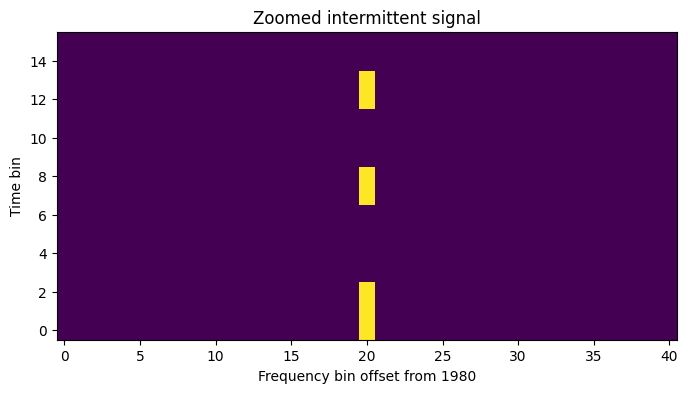

In [13]:
plt.figure(figsize=(8, 4))

plt.imshow(
    intermittent_difference[:, 1980:2021],
    aspect="auto",
    origin="lower",
)

plt.title("Zoomed intermittent signal")
plt.xlabel("Frequency bin offset from 1980")
plt.ylabel("Time bin")

plt.show()

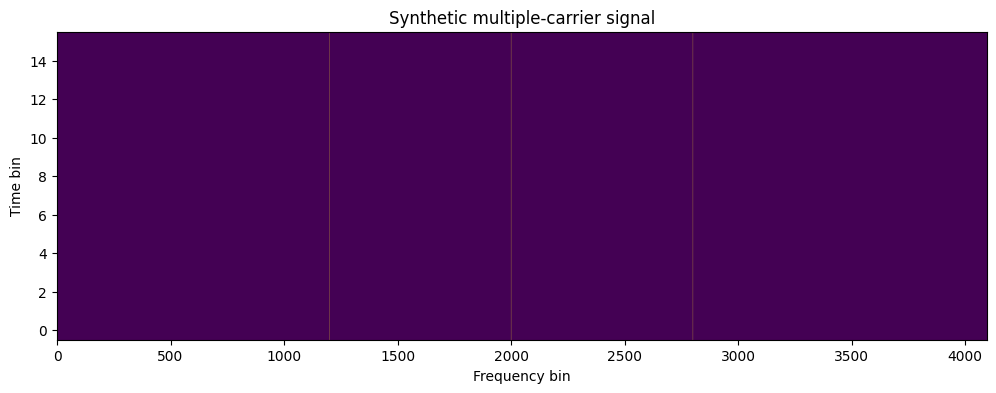

In [15]:
import importlib
import deepseti.injection.signals as signals

importlib.reload(signals)


multi_frame, multi_mask = signals.inject_multiple_carriers(
    frame,
    frequency_bins=[1200, 2000, 2800],
    snr=5.0,
)

multi_difference = multi_frame - frame

plt.figure(figsize=(12, 4))

plt.imshow(
    multi_difference,
    aspect="auto",
    origin="lower",
)

plt.title("Synthetic multiple-carrier signal")
plt.xlabel("Frequency bin")
plt.ylabel("Time bin")

plt.show()

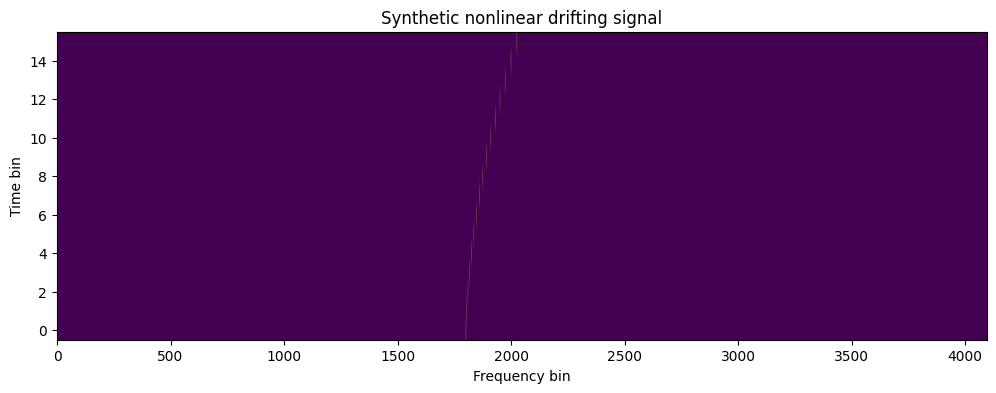

In [16]:
import importlib
import deepseti.injection.signals as signals

importlib.reload(signals)

nonlinear_frame, nonlinear_mask = signals.inject_nonlinear_drift(
    frame,
    start_frequency_bin=1800,
    linear_drift_bins_per_time=3.0,
    curvature_bins_per_time2=0.8,
    snr=5.0,
)

nonlinear_difference = nonlinear_frame - frame

plt.figure(figsize=(12, 4))

plt.imshow(
    nonlinear_difference,
    aspect="auto",
    origin="lower",
)

plt.title("Synthetic nonlinear drifting signal")
plt.xlabel("Frequency bin")
plt.ylabel("Time bin")

plt.show()

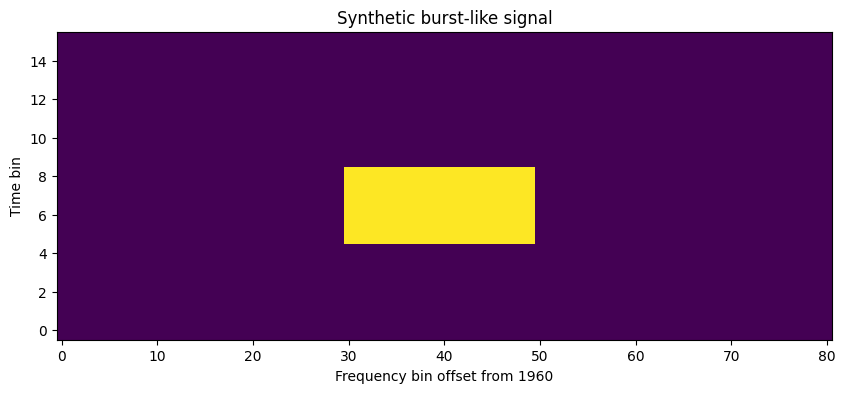

In [17]:
import importlib
import deepseti.injection.signals as signals

importlib.reload(signals)

burst_frame, burst_mask = signals.inject_burst(
    frame,
    start_time_bin=5,
    duration_bins=4,
    center_frequency_bin=2000,
    bandwidth_bins=20,
    snr=5.0,
)

burst_difference = burst_frame - frame

plt.figure(figsize=(10, 4))

plt.imshow(
    burst_difference[:, 1960:2041],
    aspect="auto",
    origin="lower",
)

plt.title("Synthetic burst-like signal")
plt.xlabel("Frequency bin offset from 1960")
plt.ylabel("Time bin")

plt.show()